In [8]:
import matplotlib as mpl
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from cmcrameri import cm
import os
from copy import deepcopy


import inferagni as ia
from inferagni.plot import truth_color, samples_color, DPI
from inferagni.util import varprops

In [5]:
%config InlineBackend.figure_format = 'retina'

In [81]:
cmap_dict = {
    "Fbol+MMW":  "Greys",
    "Fbol":      "Reds",
    "MMW":       "Blues",
    "Neither":   "Greens"
}


In [104]:
cases = {"Neither":None,  "Fbol":None, "MMW":None, "Fbol+MMW":None,}

outdir = "output/"
planet = "pi_Men_c"
end_frac = 0.05

for k in cases.keys():
    outdir_planet = os.path.join(outdir,f"{planet}({k})")
    print(outdir_planet)

    samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv" ),skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # sort samples into best-fit order
    r_phot_obs = truth.loc[truth["key"]=="r_phot"]["value"].iloc[0]
    mask = np.argsort(np.abs(samps["r_phot"].values - r_phot_obs))[::-1]
    samps = samps.iloc[mask]

    # get last samples from samps
    nsamp = int(len(samps)*end_frac)
    print(f"Number of samples: {len(samps)}")
    samps = samps.iloc[-nsamp:]

    cases[k] = {"samps":samps, "truth":truth, "cmap":cmap_dict[k], "outdir":outdir_planet}

    print(truth.keys())
    print(samps.keys())
    print("")

output/pi_Men_c(Neither)
Number of samples: 52920
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2S', 'μ_phot', 'r_phot', 'log_Kzz_max',
       'log_vmr_H2O', 'log_vmr_CO2', 'log_vmr_H2', 't_surf'],
      dtype='str')

output/pi_Men_c(Fbol)
Number of samples: 52920
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_CO2', 't_surf', 'log_vmr_H2O', 'log_Kzz_max',
       'log_vmr_H2', 'log_vmr_H2S', 'r_phot', 'μ_phot'],
      dtype='str')

output/pi_Men_c(MMW)
Number of samples: 28333
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2O', 'log_vmr_CO2', 'μ_phot', 'log_vmr_H2',
       'r_phot', 'log_Kzz_max', 't_surf', 'log_vmr_H2S'],
      dtype='str')

output/pi_Men_c(Fbol+MM

Fbol+MMW
    output/pi_Men_c(Fbol+MMW)
r_phot
    r_phot: 2.019354581832886 median
    r_phot: 2.018898132161356 truth
mass_tot
    mass_tot: 3.6715705394744873 median
    mass_tot: 3.63 truth
Teff
    Teff: 6011.916015625 median
    Teff: 5998.0 truth
instellation
    instellation: 265.9518517678396 median
    instellation: 307.875 truth
μ_phot
    μ_phot: 6.1371502876281 median
    μ_phot: 4.1000000000000005 truth
MMW
    output/pi_Men_c(MMW)
r_phot
    r_phot: 2.0188908576965328 median
mass_tot
    mass_tot: 3.582056760787964 median
Teff
    Teff: 5985.830078125 median
instellation
    instellation: 95.063333368097 median
μ_phot
    μ_phot: 6.6389069557189 median
Fbol
    output/pi_Men_c(Fbol)
r_phot
    r_phot: 2.0190125703811646 median
mass_tot
    mass_tot: 3.6756449937820435 median
Teff
    Teff: 5998.21484375 median
instellation
    instellation: 120.59529608486463 median
μ_phot
    μ_phot: 3.50131213665 median
Neither
    output/pi_Men_c(Neither)
r_phot
    r_phot: 2.018814086

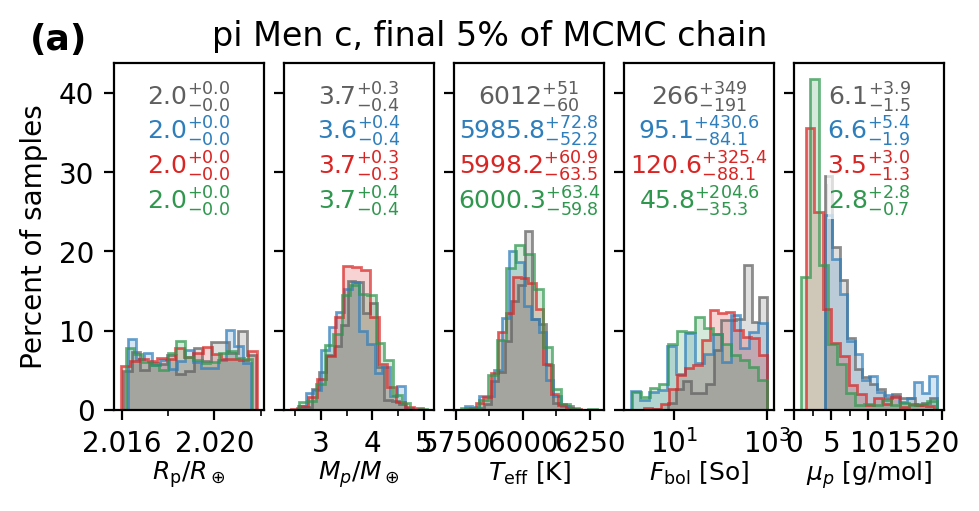

In [118]:
fig,ax = plt.subplots(1,5,figsize=(5,2.5),sharey=True)

text_bbox = dict(facecolor='w', alpha=0.7, edgecolor='none',pad=0.05)

truths = [
    "r_phot",
    "mass_tot",
    "Teff",
    "instellation",
    "μ_phot",
]

for ic, case in enumerate(list(cases.keys())[::-1]):
    samps = cases[case]["samps"]
    truth = cases[case]["truth"]
    color = plt.get_cmap(cases[case]["cmap"])(0.7)

    print(case)
    print("    " + cases[case]["outdir"])


    for i in range(5):
        k = truths[i]

        if k not in samps.keys():
            continue
        print(k)

        this_samp = ia.util.nondimen(deepcopy(samps[k]), k)

        pctle = 0.0
        ymin = np.percentile(this_samp, pctle)
        ymax = np.percentile(this_samp, 100-pctle)

        nbins = 16
        if ia.util.varprops[k].log:
            ax[i].set_xscale("log")
            bins = np.logspace(np.log10(ymin), np.log10(ymax), nbins)
        else:
            bins = np.linspace(ymin, ymax, nbins)

        # samples from mcmc
        weights = np.full_like(this_samp, 100.0/len(this_samp))
        ax[i].hist(this_samp, bins=bins,
                    weights=weights,
                    color=color, edgecolor='none',
                    histtype='bar',
                    alpha=0.2)

        ax[i].hist(this_samp, bins=bins,
                   weights=weights,
                    edgecolor=color,
                    histtype='step',
                    alpha=0.7)

        this_med = np.median(this_samp)
        this_erp = np.percentile(this_samp, 84)-this_med
        this_erm = this_med-np.percentile(this_samp, 16)

        print(f"    {k}: {this_med} median")


        # observations
        # al = 0.5

        if ic == 0:
            this_truth = deepcopy(truth.iloc[i])
            obs_val = ia.util.nondimen(this_truth["value"], k)
            # ax[i].axvline(obs_val, color=truth_color, ls="-", alpha=al)
            print(f"    {k}: {obs_val} truth")

        # obs_err_plu = obs_val + ia.util.nondimen(float(this_truth["plus"]), k)
        # # ax[i].axvline(obs_err_plu, color=truth_color, ls="--", alpha=al)

        # obs_err_min = obs_val - ia.util.nondimen(float(this_truth["minus"]), k)
        # # ax[i].axvline(obs_err_min, color=truth_color, ls="--", alpha=al)

        # text = ia.util.varprops[k].label
        # ax[i].text(0.5, 0.5, text, transform=ax[i].transAxes, ha="left", va="center",
        #                fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.1))

        ax[i].set_xlabel(ia.util.varprops[k].label_short, fontsize=9, labelpad=0.1)

        # custom tick spacing and formatter
        if ic == 0:
            fmt = "%.1f"
            match k:
                case "r_phot":
                    ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.004))
                    ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.002))
                case "mass_tot":
                    dy = 1
                    ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
                    ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))
                case "Teff":
                    ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(250))
                    ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(125))
                    fmt = "%.0f"
                case "instellation":
                    fmt = "%.0f"
                case "μ_phot":
                    # ax[i].set_xscale("log")
                    ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
                    ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(2.5))
                    # ax[i].xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))

        # annotate
        ax[i].text(0.5,0.95-ic*0.1,str(fmt)%this_med + r"$^{+" + str(fmt)%this_erp + r"}_{-" + str(fmt)%this_erm + r"}$",
                        va='top', ha='center', color=color,
                    transform=ax[i].transAxes,
                        fontsize=9, zorder=99, bbox=text_bbox)
        # ax[i].text(0.5,0.95,str(fmt)%obs_val + r"$^{+" + str(fmt)%obs_err_plu + r"}_{-" + str(fmt)%obs_err_min + r"}$",
        #                 va='top', ha='center', color=truth_color,
        #                transform=ax[i].transAxes,
        #                 fontsize=9, zorder=99, bbox=text_bbox)


fig.text(0.04,1.02, "(a)", ha="left", va="top", fontsize=13, fontweight="bold")
ax[0].set_ylabel(f"Percent of samples")
fig.align_xlabels()
fig.tight_layout(w_pad=-0.5)

planet_name = planet.replace("_", " ")
fig.suptitle(f"{planet_name}, final {end_frac*100:.0f}% of MCMC chain", fontsize=12, va='bottom', y=0.96)


fig.savefig(os.path.join(outdir,"ia_Fbol_dist.pdf"), dpi=ia.plot.DPI, bbox_inches="tight")
plt.show()

    Nsamps: 2646
    Counts: 0.0e+00 - 1.1e-02
    Nsamps: 2646
    Counts: 0.0e+00 - 9.4e-03
    Nsamps: 1416
    Counts: 0.0e+00 - 2.0e-02
    Nsamps: 1323
    Counts: 0.0e+00 - 2.3e-02
Neither
    Greens
    frac_atm        : 0.0035  (+ 0.0194 ,   0.0024)
    logZ            :-0.4151  (+ 0.6196 ,   0.9225)
Fbol
    Reds
    frac_atm        : 0.0031  (+ 0.0177 ,   0.0022)
    logZ            :-0.1858  (+ 0.4942 ,   0.8848)
MMW
    Blues
    frac_atm        : 0.0306  (+ 0.0578 ,   0.0237)
    logZ            : 0.3286  (+ 0.3738 ,   0.2405)
Fbol+MMW
    Greys
    frac_atm        : 0.0171  (+ 0.0442 ,   0.0133)
    logZ            : 0.2706  (+ 0.3478 ,   0.1912)


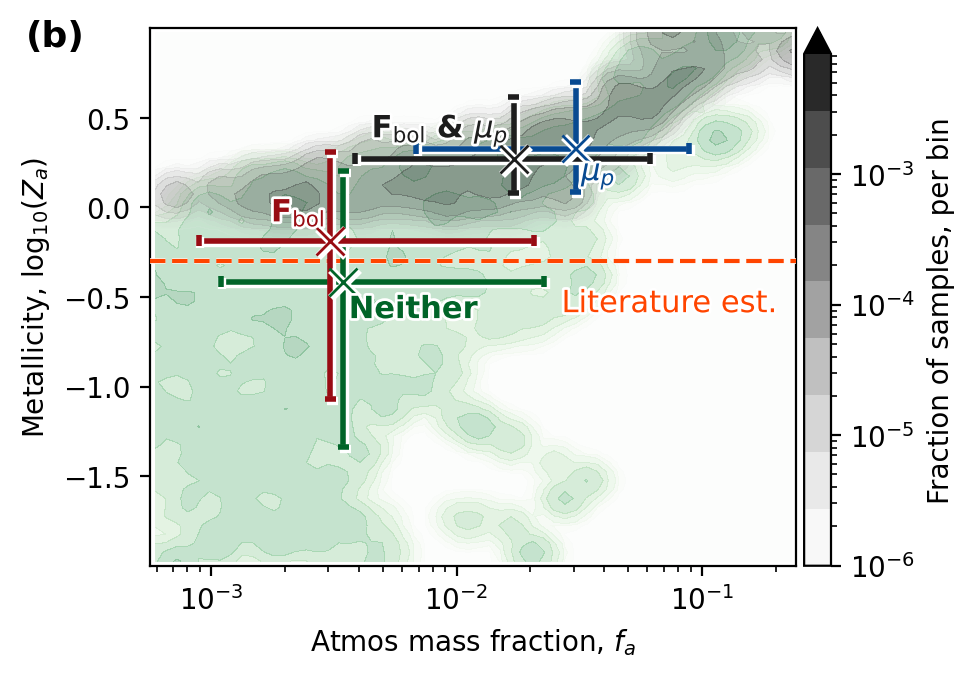

In [119]:
fig,ax = plt.subplots(1,1, figsize=(5,3.5))

xkey = "frac_atm"       ; xfmt = "%7.4f"
ykey = "logZ"    ; yfmt = "%7.4f"

nbins = 60
nlevs = 10
scat_val = 1.0
scat_al = 0.03
vmr_min = 10**(-3.5)
filter_sigma = 1.0
al_min = 0.05
al_max = 0.45

plot_types = ["contourf"]#, "scatter", ]

hist = {}
xmin, xmax = np.inf, -np.inf
ymin, ymax = np.inf, -np.inf
nsamps = 1
for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if xkey.startswith("log_vmr"):
        x = np.clip(x, np.log10(vmr_min), 0)
    if ykey.startswith("log_vmr"):
        y = np.clip(y, np.log10(vmr_min), 0)

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    xmin = min(xmin, np.amin(x))
    xmax = max(xmax, np.amax(x))
    ymin = min(ymin, np.amin(y))
    ymax = max(ymax, np.amax(y))

    nsamps = max(nsamps, len(x))

min_counts = 1e-6
max_counts = 1e-5
for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    counts, xbins, ybins = np.histogram2d(x,y, bins=nbins, range=[[xmin,xmax],[ymin,ymax]])

    nsamps = len(x)
    print(f"    Nsamps: {nsamps}")

    counts /= nsamps

    print(f"    Counts: {np.amin(counts):.1e} - {np.amax(counts):.1e}")

    max_counts = max(max_counts,np.amax(counts))

    if varprops[xkey].log:
        xbins = 10**xbins
    if varprops[ykey].log:
        ybins = 10**ybins

    hist[k] = (counts.T, xbins, ybins)

_pe_text = [mpl.patheffects.Stroke(linewidth=2, foreground='w'), mpl.patheffects.Normal()]
_pe_scat = [mpl.patheffects.Stroke(offset=(0.7,-0.7),linewidth=3, foreground='w'), mpl.patheffects.Normal()]

zorder = 20
for k in cases.keys():
    print(k)
    print("    "+cmap_dict[k])


    cmap_orig = deepcopy(plt.get_cmap(cmap_dict[k]))
    cmap = cmap_orig(np.arange(cmap_orig.N))
    cmap[:,-1] =  np.linspace(al_min, al_max, cmap_orig.N)
    cmap = mpl.colors.ListedColormap(cmap)
    cmap.set_under([0,0,0,0])

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    counts = np.clip(hist[k][0], min_counts, max_counts)

    xbins = hist[k][1]
    ybins = hist[k][2]
    xbins_mid = (xbins[1:]+xbins[:-1])/2
    ybins_mid = (ybins[1:]+ybins[:-1])/2

    norm = mpl.colors.LogNorm(vmin=min_counts, vmax=max_counts)
    levels = 10**np.arange(np.log10(min_counts), np.log10(max_counts), (np.log10(max_counts)-np.log10(min_counts))/nlevs)
    # levels = nlevs

    # smooth data before plotting on contour
    if filter_sigma > 0:
        counts = sp.ndimage.gaussian_filter(counts, sigma=filter_sigma)

    for i,plot_type in enumerate(plot_types):

        if plot_type=="scatter":
            ax.scatter(x,y, color=cmap_orig(scat_val), alpha=scat_al, s=3, edgecolors='none',
                       rasterized=True, zorder=zorder+i)

        if k not in ("Fbol+MMW", "Neither"):
            continue

        if plot_type == "hist2d":
            ax.pcolormesh(xbins_mid, ybins_mid, counts,
                                cmap=cmap, norm=norm, rasterized=True, zorder=zorder+i
                                )

        elif plot_type == "contourf":
            ax.contourf(xbins_mid, ybins_mid, counts, levels=levels,
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )

        elif plot_type == "contour":
            ax.contour(xbins_mid, ybins_mid, counts, levels=levels, linewidths=0.7,
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )


    lbl = f"{k}"
    col = cmap(0.9)
    x0 = np.median(x)
    y0 = np.median(y)
    xerr = [[x0-np.percentile(x, 16)], [np.percentile(x, 84)-x0]]
    yerr = [[y0-np.percentile(y, 16)], [np.percentile(y, 84)-y0]]
    print(f"    {xkey:16s}:" + str(xfmt)%x0  + "  (+" + str(xfmt)%xerr[1][0] + " ,  " + str(xfmt)%xerr[0][0] + ")")
    print(f"    {ykey:16s}:" + str(yfmt)%y0  + "  (+" + str(yfmt)%yerr[1][0] + " ,  " + str(yfmt)%yerr[0][0] + ")")
    ax.errorbar([x0], [y0], xerr=xerr, yerr=yerr,
                color=col, alpha=1, path_effects=_pe_scat, capsize=2, capthick=2, elinewidth=2,
                marker='x', markersize=10, label=lbl,zorder=50)

    if "Fbol" in lbl:
        offset = (-2,10)
        ha = 'right'
    else:
        offset = (2,-10)
        ha = 'left'
    lbl = lbl.replace("Fbol",r"F$_{\text{bol}}$")
    lbl = lbl.replace("MMW",r"$\mu_p$")
    lbl = lbl.replace("+"," & ")
    ax.annotate(lbl, (x0, y0), offset, color=col, weight='bold', ha=ha, va='center', alpha=1,
                textcoords='offset points',zorder=52, fontsize=11, path_effects=_pe_text)


if plot_type != ["scatter"]:
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, extend='max', alpha=1,
                        label="Fraction of samples, per bin", boundaries=levels)
    cbar.ax.set_yscale("log")
    cbar.ax.tick_params(axis='y', which='major', labelsize=10)
    # cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.0f'))

# obs
yobs = np.log10(0.5)
ax.axhline(y=yobs, ls='--', color=truth_color, zorder=zorder+20, path_effects=_pe_text)
ax.annotate("Literature est.",(np.amax(xbins_mid),yobs), xytext=(-5,-10), textcoords='offset points',
                 ha='right', va='top', rotation=0, rotation_mode='anchor', zorder=zorder+21,
                 color=truth_color, fontsize=11, path_effects=_pe_text)


ax.set_ylabel(varprops[ykey].label)
ax.set_xlabel(varprops[xkey].label)
if varprops[xkey].log:
    ax.set_xscale("log")
if varprops[ykey].log:
    ax.set_yscale("log")

ax.set_xlim(np.amin(xbins), np.amax(xbins))
ax.set_ylim(np.amin(ybins), np.amax(ybins))

fig.text(0.04,0.97, "(b)", ha="left", va="top", fontsize=13, fontweight="bold")

# ax.legend(ncols=2)
# ax.set_title(planet.replace("_"," "))
fig.tight_layout()


fig.savefig(os.path.join(outdir,"ia_Fbol.pdf"),  dpi=DPI, bbox_inches="tight")
plt.show()